In [1]:
import numpy as np
import random

GRID_ROWS = 6
GRID_COLUMNS = 9

# shortcut gridworld
shortcut_gw = np.ones((GRID_ROWS, GRID_COLUMNS), dtype=np.int8)

# invalid locations
shortcut_gw[2, 1:9] = 0

start_location = np.array([0, 3])

goal = np.array([GRID_ROWS - 1, GRID_COLUMNS - 1])

# allowed actions
actions = np.array([
    [1, 0],     #up     - 0
    [0, 1],     #right  - 1
    [-1, 0],    #down   - 2
    [0, -1]     #left   - 3
])

num_actions = len(actions)

In [2]:
def get_valid_action_indices(grid_location):

    valid = []
    for i, action in enumerate(actions):
        projected_location = grid_location + action
        if projected_location[0] >= 0 and projected_location[0] < GRID_ROWS and projected_location[1] >= 0 \
            and projected_location[1] < GRID_COLUMNS and shortcut_gw[*projected_location]:
            valid.append(i)
    return valid

In [3]:
# Q(s, a) ∈ R (arbitrarily), for all s ∈ S, a ∈ A(s)

action_value = np.zeros((GRID_ROWS, GRID_COLUMNS, num_actions), dtype=np.float32)

# M(s, a)
model = {}

In [4]:
alpha = 0.1 # step-size
gamma = 0.95 # discounted
epsilon = 0.1

In [5]:
def choose_epsilon_greedy_action_index(s, Q, epsilon):
    Q_s = Q[*s]
    valid_actions = np.array(get_valid_action_indices(s), dtype=int)
    
    if epsilon==0.0:
        return valid_actions[np.argmax(Q_s[valid_actions])]
    
    k = len(valid_actions)

    q_valid = Q_s[valid_actions]
    max_q = np.max(q_valid)
    greedy_actions = valid_actions[q_valid == max_q]   # possibly multiple
    m = len(greedy_actions)

    p_a = np.zeros(num_actions, dtype=np.float32)

    # exploration mass over valid actions
    p_a[valid_actions] = epsilon / k

    # greedy mass split over all greedy ties
    p_a[greedy_actions] += (1.0 - epsilon) / m

    return np.random.choice(num_actions, p=p_a)

In [6]:
def evaluate_next_state(current_state, action_index):
    next_state = current_state + actions[action_index]
    return np.clip(next_state, [0,0], [5, 8])

In [7]:
def run_dynaq_episode(epsilon, planning_n, time_step, cumulative_r, cummulative_reward_for_t):
    """
    Runs ONE DynaQ episode

    Returns:
        episode: list of (state, action_idx, reward, next_state)
    """
    state = start_location.copy() # (a)
    
    episode = []
    
    while True:
        action_index_per_Q = choose_epsilon_greedy_action_index(state, action_value, epsilon) # (b)

        next_state = evaluate_next_state(state, action_index_per_Q)  # (c)
        done = np.array_equal(next_state, goal)
        reward = 1 if done else 0

        cumulative_r += reward
        cummulative_reward_for_t.append(cumulative_r)

        # record step
        episode.append((state.copy(),
                        int(action_index_per_Q),
                        int(reward),
                        next_state.copy()))

        if done:
            max_Q = 0
            # Q(S, A) <- Q(S, A) + α [R + γ*0 - Q(S, A)]
        else:
            valid_actions = get_valid_action_indices(next_state)
            max_Q = np.max(action_value[tuple(next_state)][valid_actions])

        # Q(S, A) <- Q(S, A) + α [R + γ*(maxₐQ(S´, a)) - Q(S, A)]
        action_value[(*state, action_index_per_Q)] += alpha * (reward + (gamma * max_Q) - action_value[(*state, action_index_per_Q)]) # (d)
        
        model[(*state, action_index_per_Q)] = (reward, next_state) # (e)

        for _ in range(planning_n): # (f)
            *planning_s, planning_a = random.choice(list(model.keys()))
            
            r, s_prime = model[(*planning_s, planning_a)]
            
            if np.array_equal(s_prime, goal):
                max_planning_Q = 0
            else:
                valid_planning_actions = get_valid_action_indices(s_prime)
                max_planning_Q = np.max(action_value[tuple(s_prime)][valid_planning_actions])

            action_value[(*planning_s, planning_a)] += alpha * (r + (gamma * max_planning_Q) - action_value[(*planning_s, planning_a)])

        time_step += 1
        if time_step == 3000:
            # change maze - invalid locations
            shortcut_gw[2, 8:9] = 1

        if done:
            break
        
        state = next_state

    return episode, time_step, cumulative_r, cummulative_reward_for_t


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from IPython import display
import time

def visualize_maze_episode(
    episode,
    rows=6,
    cols=9,
    start=(0, 3),
    goal=(5, 8),
    action_deltas=None,          # dict mapping action_idx -> (dy, dx)
    sleep=0.05,
    show_trail=True,
    title_prefix="Episode",
    total_steps=None
):
    """
    Animate one maze episode.
    episode: list of tuples (state, action_idx, reward, next_state)
    """
    
    # Background: 0=obstacle, 1=empty, 2=start, 3=goal
    display_grid = np.zeros((rows, cols), dtype=int)
    display_grid[shortcut_gw == 1] = 1  # valid cells
    display_grid[shortcut_gw == 0] = 0  # obstacles
    display_grid[start] = 2
    display_grid[goal] = 3

    cmap = plt.cm.colors.ListedColormap(["black", "white", "#90ee90", "#f08080"])  # obstacle, empty, start, goal

    fig, ax = plt.subplots(figsize=(9, 6))
    fig.subplots_adjust(top=0.88)

    trail = []

    for t, step in enumerate(episode):
        state = step[0]
        action_idx = step[1] if len(step) > 1 else None
        reward = step[2] if len(step) > 2 else None
        next_state = step[3] if len(step) > 3 else None

        y, x = int(state[0]), int(state[1])
        trail.append((y, x))

        ax.clear()
        ax.imshow(display_grid, origin="lower", cmap=cmap, vmin=0, vmax=3)

        # Grid lines
        ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
        ax.grid(which="minor", color="gray", linewidth=0.5)
        ax.tick_params(which="both", length=0)
        ax.set_xticks(np.arange(cols))
        ax.set_yticks(np.arange(rows))

        # Trail
        if show_trail and len(trail) > 1:
            xs = [p[1] for p in trail]
            ys = [p[0] for p in trail]
            ax.plot(xs, ys, "b-", linewidth=2, alpha=0.6)

        # Current agent position
        ax.plot(x, y, "bo", markersize=12)

        # Next position marker (if present)
        if next_state is not None:
            ny, nx = int(next_state[0]), int(next_state[1])
            ax.plot(nx, ny, "rx", markersize=9)

        # Action arrow
        if action_deltas is not None and action_idx is not None:
            dy, dx = action_deltas[int(action_idx)]
            arrow = FancyArrowPatch(
                (x, y), (x + dx * 0.5, y + dy * 0.5),
                arrowstyle="->", mutation_scale=15, color="blue", linewidth=2
            )
            ax.add_patch(arrow)

        # Title
        info = f"{title_prefix} | step {t}"
        if total_steps is not None:
            info += f" | total steps: {total_steps + t}"
        if action_idx is not None:
            info += f" | a={action_idx}"
        if reward is not None:
            info += f" | r={reward}"
            
        ax.set_title(info, fontsize=12)

        display.clear_output(wait=True)
        display.display(fig)
        time.sleep(sleep)

        if tuple(state) == goal or (next_state is not None and tuple(next_state) == tuple(goal)):
            break

    plt.close(fig)


def plot_cumulative_reward(cumulative_rewards, title="Dyna-Q"):
    """
    Plot cumulative reward vs. timesteps (Figure 8.4 style)
    """
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_rewards, linewidth=1)
    plt.xlabel("Time steps")
    plt.ylabel("Cumulative reward")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

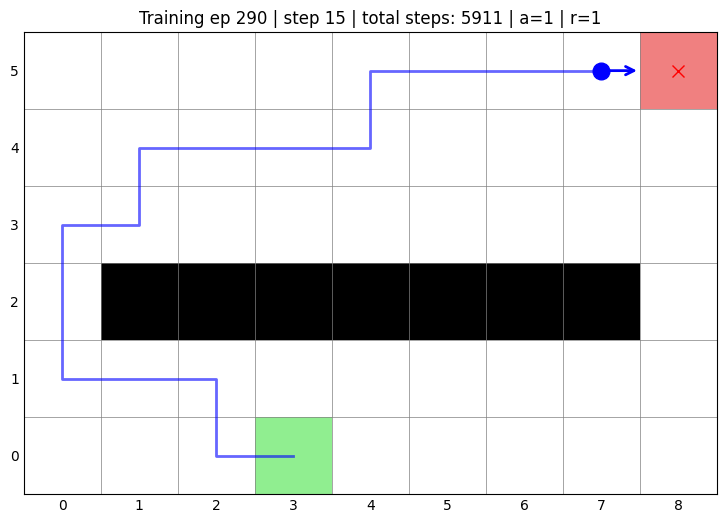

episode=291, t=5932
episode=292, t=5950
episode=293, t=5968
episode=294, t=5986


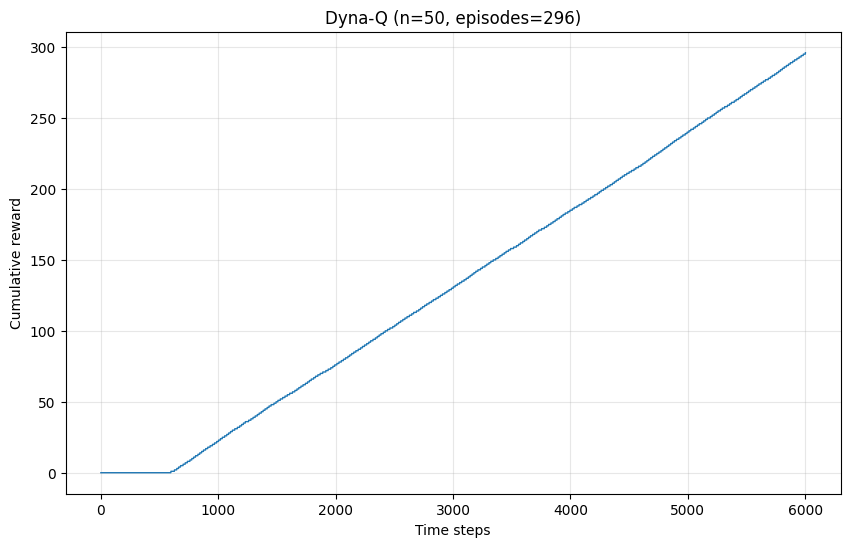

In [9]:
num_episodes = 500
planning_n = 50

time_step = 0
cumulative_r = 0
cumulative_reward_for_t = []

num_episodes_ran = 0

for e in range(num_episodes):
    episode, time_step, cumulative_r, cumulative_reward_for_t = run_dynaq_episode(
        epsilon=epsilon,
        planning_n=planning_n,
        time_step=time_step,
        cumulative_r=cumulative_r,
        cummulative_reward_for_t=cumulative_reward_for_t
    )
    num_episodes_ran+=1

    if time_step >= 6000:
        break

    print(f'episode={e}, t={time_step}')

    if (e % 10 == 0) and time_step > 3000:
        visualize_maze_episode(
            episode=episode,
            rows=GRID_ROWS,
            cols=GRID_COLUMNS,
            start=tuple(start_location),
            goal=tuple(goal),
            action_deltas=actions,
            sleep=0.03,
            title_prefix=f"Training ep {e}",
            total_steps=time_step - len(episode)
        )

# Plot cumulative reward
plot_cumulative_reward(cumulative_reward_for_t, title=f"Dyna-Q (n={planning_n}, episodes={num_episodes_ran})")